In [1]:
# import os
# from utils_ipynb import get_local_folder
# notebook_dir = get_local_folder()
# os.chdir(f"{notebook_dir}/..")
import os
import json
import matplotlib.pyplot as plt
os.chdir(f"/home/zx/nas/GitRepos/kma")


## MisInfo

In [10]:
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_misinfo.json"
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_misinfo_epoch_1.json"
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_misinfo_epoch_5.json"
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_misinfo_epoch_10.json"
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_misinfo_epoch_15.json"
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_misinfo_epoch_20.json"

from utils import init_plot
import json

data = json.load(open(edit_result_json, "r"))

total_splits = len(data)
print("Total Data Split: ", total_splits)


Total Data Split:  100


[54, 88, 51, 18, 53, 24, 86, 99, 45, 50, 5, 43, 40, 11, 49, 76, 62, 64, 65, 72, 39, 9, 30, 26, 59, 32, 28, 31, 22, 77, 16, 82, 98, 44, 81, 94, 93, 3, 91, 8, 73, 85, 97, 34, 63, 1, 23, 25, 41, 56, 47, 35, 60, 70, 69, 42, 46, 95, 36, 48, 29, 68, 14, 21, 66, 10, 13, 67, 61, 55, 83, 19, 90, 89, 2, 17, 71, 78, 58, 27, 52, 0, 84, 75, 74, 37, 38, 7, 6, 87, 15, 20, 80, 92, 4, 33, 96, 12, 79, 57]
Least 10 split with least loss steps
Data Split Idx: 54, Steps: 22, Start Loss: 8.6875, loss_after_attack: 0.228515625, loss_after_agg: 6.28125, post_edit_acc:1.0
Data Split Idx: 88, Steps: 24, Start Loss: 9.25, loss_after_attack: 0.1494140625, loss_after_agg: 6.21875, post_edit_acc:1.0
Data Split Idx: 51, Steps: 24, Start Loss: 7.84375, loss_after_attack: 0.23828125, loss_after_agg: 6.0, post_edit_acc:1.0
Data Split Idx: 18, Steps: 24, Start Loss: 7.96875, loss_after_attack: 0.055419921875, loss_after_agg: 5.9375, post_edit_acc:1.0
Data Split Idx: 53, Steps: 24, Start Loss: 8.75, loss_after_attack: 0.

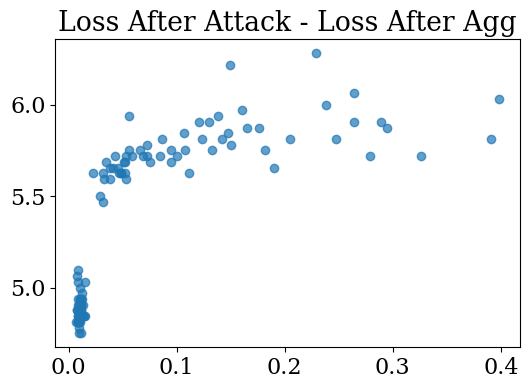

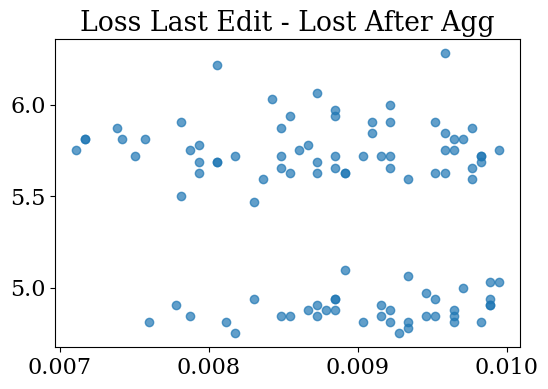

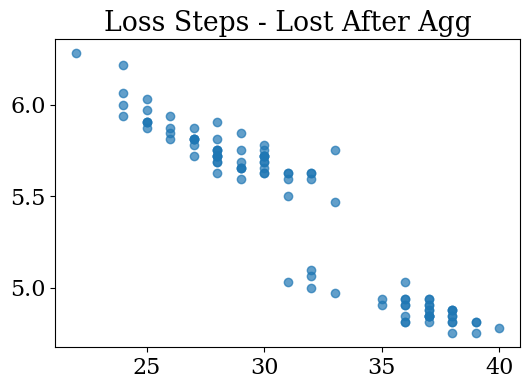

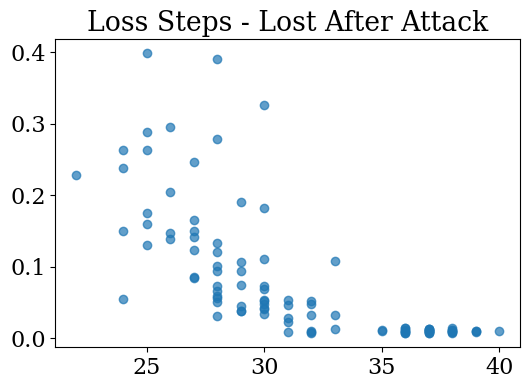

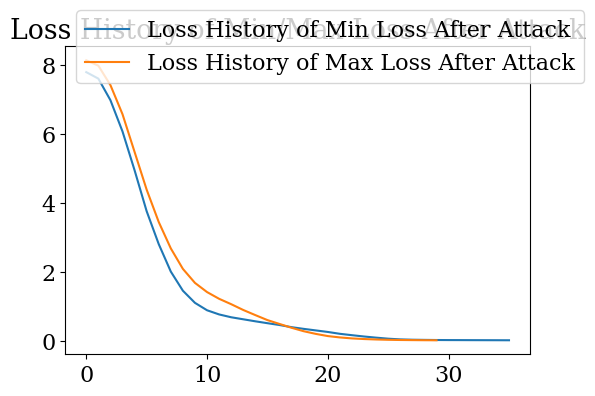

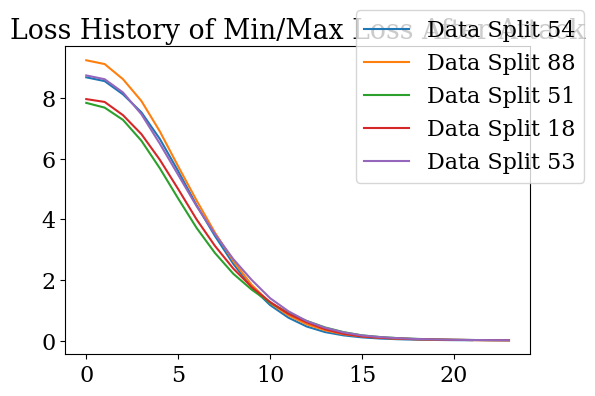

In [11]:
total_splits = len(data)

### loss after agg与loss after attack关系
loss_after_agg, loss_after_attack = [], []
edit_loss_history = [] 
post_edit_acc = []

for d in data:
    loss_after_agg.append(d["loss_after_agg"])
    loss_after_attack.append(d["loss_after_attack"])
    edit_loss_history.append(d["loss_history"][0])
    post_edit_acc.append(d["edit_metric"][0]["post"]["rewrite_acc"][0])

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(loss_after_attack, loss_after_agg, alpha=0.7)
ax.set_title("Loss After Attack - Loss After Agg")

# ### attack loss 最终值 与loss after agg关系
edit_loss_last_step = [ loss[-1] for loss in edit_loss_history]

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]


ax.scatter(edit_loss_last_step, loss_after_agg, alpha=0.7)
ax.set_title("Loss Last Edit - Lost After Agg")

# ### attack loss 步数 与loss after agg关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_agg, alpha=0.7)
ax.set_title("Loss Steps - Lost After Agg")

# ### attack loss 步数 与loss after attack关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_attack, alpha=0.7)
ax.set_title("Loss Steps - Lost After Attack")

## 打印loss steps 最少的data split
import numpy as np
sorted_indices = np.argsort(np.array(edit_loss_total_steps)).tolist()
print(sorted_indices)

print("================")
print("Least 10 split with least loss steps")
for i in sorted_indices[:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")

least_loss_steps_idxs = sorted_indices[:10]
print(least_loss_steps_idxs)

print("================")
print("Largest 10 split with least loss steps")
for i in sorted_indices[::-1][:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")

print("================")
print("Least 10 split with least loss after attack")
sorted_indices = np.argsort(np.array(loss_after_attack)).tolist()
for i in sorted_indices[:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")

select_less_loss_after_attack_idx = sorted_indices[0]


print("================")
print("Largest 10 split with least loss after attack")
sorted_indices = np.argsort(np.array(loss_after_attack)).tolist()
for i in sorted_indices[::-1][:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
select_large_loss_after_attack_idx = sorted_indices[::-1][2]



fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

print(edit_loss_history[select_less_loss_after_attack_idx])
print(edit_loss_history[select_large_loss_after_attack_idx])

ax.plot(edit_loss_history[select_less_loss_after_attack_idx], label="Loss History of Min Loss After Attack")
ax.plot(edit_loss_history[select_large_loss_after_attack_idx], label="Loss History of Max Loss After Attack")
ax.set_title("Loss History of Min/Max Loss After Attack")

fig.legend()



## Plot loss history of less loss steps
print(least_loss_steps_idxs)

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

for idx in least_loss_steps_idxs[:5]:
    ax.plot(edit_loss_history[idx], label=f"Data Split {idx}")
ax.set_title("Loss History of Min/Max Loss After Attack")

fig.legend()

In [ ]:

split_data_val = {
    68: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.04, 0.04, 0.04, 0.06, 0.28],
    41: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.16, 0.14, 0.14, 0.16, 0.22],
    94: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.28, 0.24, 0.34, 0.3, 0.86], 
    62: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.02, 0.0, 0.24, 0.26, 0.24, 0.22, 0.26, 0.5, 0.54, 0.5, 0.56, 0.86], 
    45: [0.0, 0.0, 0.04, 0.0, 0.0, 0.0, 0.0, 0.16, 0.04, 0.1, 0.36, 0.52, 0.42, 0.3, 0.34, 0.74, 0.8, 0.8, 0.76, 0.94], 
    88: [0.0, 0.0, 0.1, 0.04, 0.0, 0.0, 0.0, 0.28, 0.06, 0.26, 0.56, 0.6, 0.62, 0.44, 0.5, 0.82, 0.88, 0.84, 0.86, 0.94],
    
    53: [0.0, 0.0, 0.06, 0.0, 0.0, 0.0, 0.0, 0.18, 0.1, 0.14, 0.46, 0.64, 0.58, 0.44, 0.44, 0.8, 0.84, 0.86, 0.86, 0.98],
    24: [0.0, 0.0, 0.04, 0.0, 0.0, 0.0, 0.0, 0.22, 0.02, 0.14, 0.52, 0.54, 0.56, 0.44, 0.44, 0.82, 0.86, 0.86, 0.86, 0.94],
    51: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08, 0.0, 0.0, 0.28, 0.3, 0.28, 0.2, 0.22, 0.52, 0.52, 0.5, 0.54, 0.76],
    54: [0.0, 0.0, 0.32, 0.08, 0.0, 0.0, 0.0, 0.52, 0.48, 0.54, 0.74, 0.7, 0.62, 0.62, 0.68, 0.9, 0.86, 0.88, 0.9, 0.96],
    
    "least_agg_rank": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.02, 0.02, 0.02, 0.16]
}


# Data Split Idx: 53, Steps: 21, loss_after_attack: 0.11383056640625, loss_after_agg: 5.90234375, post_edit_acc:1.0
# Data Split Idx: 24, Steps: 21, loss_after_attack: 0.2288818359375, loss_after_agg: 5.82421875, post_edit_acc:1.0
# Data Split Idx: 51, Steps: 21, loss_after_attack: 0.826171875, loss_after_agg: 5.765625, post_edit_acc:1.0
#
# Data Split Idx: 54, Steps: 22, loss_after_attack: 0.1185302734375, loss_after_agg: 5.921875, post_edit_acc:1.0
# Data Split Idx: 88, Steps: 22, loss_after_attack: 0.2220458984375, loss_after_agg: 5.97265625, post_edit_acc:1.0



## Bias

In [16]:
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_bias.json"

from utils import init_plot
import json

data = json.load(open(edit_result_json, "r"))

total_splits = len(data)
print("Total Data Split: ", total_splits)


Total Data Split:  100


[38, 42, 16, 83, 93, 46, 45, 13, 55, 50, 54, 68, 89, 69, 27, 1, 47, 58, 72, 70, 79, 91, 6, 41, 35, 20, 86, 25, 96, 84, 18, 76, 5, 87, 99, 10, 49, 9, 37, 21, 85, 36, 63, 64, 59, 78, 88, 39, 44, 95, 7, 56, 48, 26, 30, 66, 74, 0, 11, 14, 71, 52, 57, 3, 92, 33, 81, 23, 24, 80, 2, 15, 12, 97, 61, 60, 40, 4, 51, 94, 8, 17, 22, 75, 77, 82, 19, 29, 31, 90, 65, 67, 62, 34, 98, 53, 43, 28, 73, 32]
Least 10 split with least loss steps
Data Split Idx: 38, Steps: 28, Start Loss: 11.6875, loss_after_attack: 0.0228271484375, loss_after_agg: 8.625, post_edit_acc:1.0
Data Split Idx: 42, Steps: 29, Start Loss: 12.0, loss_after_attack: 0.022216796875, loss_after_agg: 8.4375, post_edit_acc:1.0
Data Split Idx: 16, Steps: 30, Start Loss: 10.8125, loss_after_attack: 0.1103515625, loss_after_agg: 8.0625, post_edit_acc:1.0
Data Split Idx: 83, Steps: 30, Start Loss: 11.3125, loss_after_attack: 0.0101318359375, loss_after_agg: 8.375, post_edit_acc:1.0
Data Split Idx: 93, Steps: 30, Start Loss: 11.5625, loss_afte

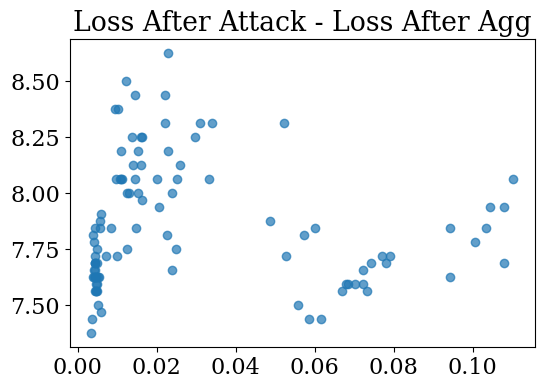

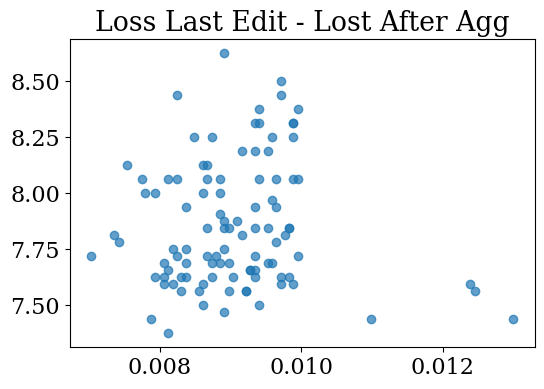

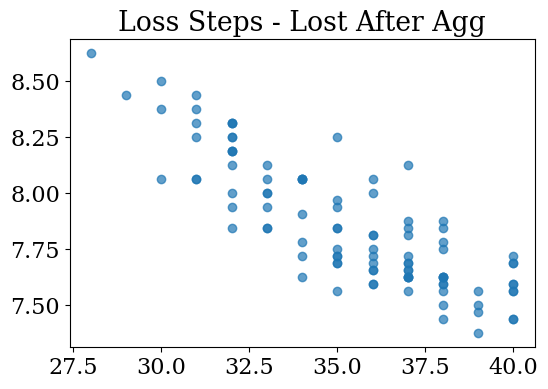

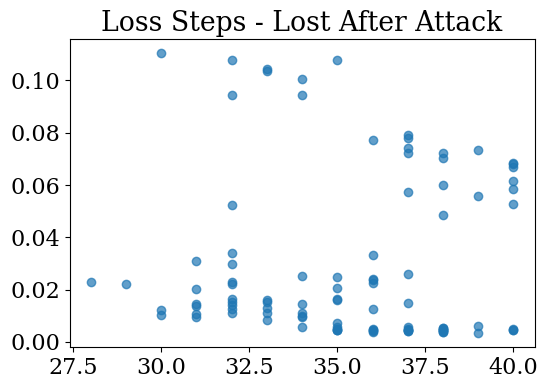

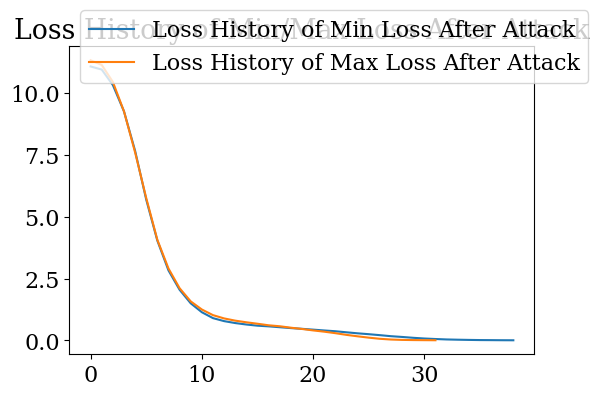

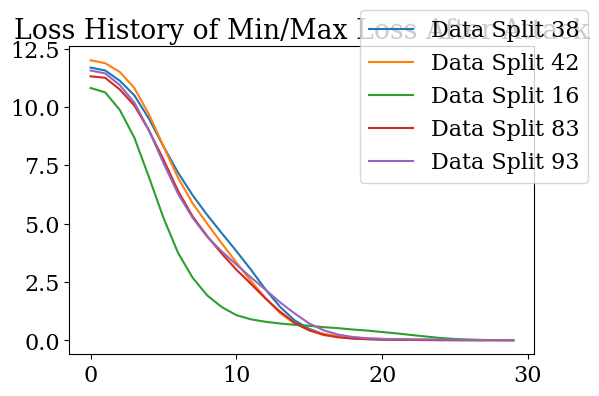

In [18]:
total_splits = len(data)

### loss after agg与loss after attack关系
loss_after_agg, loss_after_attack = [], []
edit_loss_history = [] 
post_edit_acc = []

for d in data:
    loss_after_agg.append(d["loss_after_agg"])
    loss_after_attack.append(d["loss_after_attack"])
    edit_loss_history.append(d["loss_history"][0])
    post_edit_acc.append(d["edit_metric"][0]["post"]["rewrite_acc"][0])

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(loss_after_attack, loss_after_agg, alpha=0.7)
ax.set_title("Loss After Attack - Loss After Agg")

# ### attack loss 最终值 与loss after agg关系
edit_loss_last_step = [ loss[-1] for loss in edit_loss_history]

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]


ax.scatter(edit_loss_last_step, loss_after_agg, alpha=0.7)
ax.set_title("Loss Last Edit - Lost After Agg")

# ### attack loss 步数 与loss after agg关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_agg, alpha=0.7)
ax.set_title("Loss Steps - Lost After Agg")

# ### attack loss 步数 与loss after attack关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_attack, alpha=0.7)
ax.set_title("Loss Steps - Lost After Attack")

## 打印loss steps 最少的data split
import numpy as np
sorted_indices = np.argsort(np.array(edit_loss_total_steps)).tolist()
print(sorted_indices)

print("================")
print("Least 10 split with least loss steps")
for i in sorted_indices[:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")

least_loss_steps_idxs = sorted_indices[:10]
print(least_loss_steps_idxs)

print("================")
print("Largest 10 split with least loss steps")
for i in sorted_indices[::-1][:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")

print("================")
print("Least 10 split with least loss after attack")
sorted_indices = np.argsort(np.array(loss_after_attack)).tolist()
for i in sorted_indices[:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")

select_less_loss_after_attack_idx = sorted_indices[0]


print("================")
print("Largest 10 split with least loss after attack")
sorted_indices = np.argsort(np.array(loss_after_attack)).tolist()
for i in sorted_indices[::-1][:10]:
    # print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, Start Loss: {edit_loss_history[i][0]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")
select_large_loss_after_attack_idx = sorted_indices[::-1][2]



fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

print(edit_loss_history[select_less_loss_after_attack_idx])
print(edit_loss_history[select_large_loss_after_attack_idx])

ax.plot(edit_loss_history[select_less_loss_after_attack_idx], label="Loss History of Min Loss After Attack")
ax.plot(edit_loss_history[select_large_loss_after_attack_idx], label="Loss History of Max Loss After Attack")
ax.set_title("Loss History of Min/Max Loss After Attack")

fig.legend()



## Plot loss history of less loss steps
print(least_loss_steps_idxs)

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

for idx in least_loss_steps_idxs[:5]:
    ax.plot(edit_loss_history[idx], label=f"Data Split {idx}")
ax.set_title("Loss History of Min/Max Loss After Attack")

fig.legend()

